# Pedersen Tables 6.5 and 6.6: multiphase PT flash

Pedersen et al., *Phase Behavior of Petroleum Reservoir Fluids*, 3rd ed.
(2024), §6.3.3, Tables 6.5-6.6,
[doi:10.1201/9780429457418](https://doi.org/10.1201/9780429457418), publish a
13-component PR characterization and a vapor-liquid-liquid flash at 52 bar
and −72°C.

This notebook:

1. reconstructs the model from the printed critical constants;
2. solves the three-phase material balance and fugacity equations with the
   autodiff Newton acceleration in `torch-flash`;
3. compares zero BIPs with Pedersen Table 4.2 BIPs; and
4. quantifies the reproducibility limit caused by rounded pseudo-component
   constants and the unreported BIP convention used for Table 6.6.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from torch_flash import ChemicalState, multiphase_flash, peng_robinson_1978
from torch_flash.components import ComponentSet
from torch_flash.exceptions import ExperimentalModelWarning
from torch_flash.parameters import pedersen_binary_interaction

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
names = (
    "nitrogen",
    "carbon_dioxide",
    "methane",
    "ethane",
    "propane",
    "isobutane",
    "n_butane",
    "isopentane",
    "n_pentane",
    "n_hexane",
    "n_heptane",  # labels stand for the printed C7-C9 pseudo-component
    "n_octane",  # labels stand for the printed C10-C13 pseudo-component
    "n_decane",  # labels stand for the printed C14-C55 pseudo-component
)
feed_percent = torch.tensor(
    [0.08, 2.01, 82.51, 5.81, 2.88, 0.56, 1.24, 0.52, 0.60, 0.72, 1.66, 0.91, 0.49]
)
critical_temperature = (
    torch.tensor(
        [
            -147.0,
            31.1,
            -82.6,
            32.3,
            96.7,
            135.0,
            152.1,
            187.3,
            196.5,
            234.3,
            280.4,
            352.5,
            473.1,
        ]
    )
    + 273.15
)
critical_pressure = (
    torch.tensor(
        [
            33.94,
            73.76,
            46.00,
            48.84,
            42.46,
            36.48,
            38.00,
            33.84,
            33.74,
            29.69,
            26.72,
            21.29,
            16.67,
        ]
    )
    * 1.0e5
)
acentric_factor = torch.tensor(
    [
        0.040,
        0.225,
        0.008,
        0.098,
        0.152,
        0.176,
        0.193,
        0.227,
        0.251,
        0.296,
        0.373,
        0.518,
        0.803,
    ]
)
# Molar mass does not enter the PR phase-equilibrium equations. Ones make that
# irrelevance explicit rather than inventing unreported lump molecular masses.
components = ComponentSet(
    names,
    critical_temperature,
    critical_pressure,
    acentric_factor,
    torch.ones(13),
)

Table 6.6 phase order below is liquid I, gas, liquid II, matching
`torch-flash`'s reference-liquid convention.

In [3]:
book_liquid_1_percent = torch.tensor(
    [0.08, 1.88, 87.95, 5.28, 2.17, 0.38, 0.76, 0.28, 0.29, 0.29, 0.48, 0.14, 0.01]
)
book_gas_percent = torch.tensor(
    [0.18, 1.08, 96.45, 1.86, 0.33, 0.03, 0.05, 0.01, 0.01, 0.0, 0.0, 0.0, 0.0]
)
book_liquid_2_percent = torch.tensor(
    [0.05, 2.36, 75.66, 7.28, 4.00, 0.81, 1.83, 0.79, 0.93, 1.14, 2.73, 1.54, 0.87]
)
book_phase_compositions = torch.stack(
    (
        book_liquid_1_percent / book_liquid_1_percent.sum(),
        book_gas_percent / book_gas_percent.sum(),
        book_liquid_2_percent / book_liquid_2_percent.sum(),
    )
)
book_phase_fractions = torch.tensor([26.15, 17.51, 56.33]) / 100.0
safe_gas = torch.clamp_min(book_phase_compositions[1], 1.0e-8)
initial_k = torch.stack(
    (
        safe_gas / book_phase_compositions[0],
        book_phase_compositions[2] / book_phase_compositions[0],
    )
)
state = ChemicalState(
    torch.tensor(201.15),
    torch.tensor(52.0e5),
    feed_percent,
)


def solve_model(model):
    """Run the fixed-three-phase flash while retaining numerical diagnostics."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ExperimentalModelWarning)
        return multiphase_flash(
            model,
            state,
            initial_k_values=initial_k,
            tolerance=1.0e-10,
            max_iterations=30,
        )


models = {
    "PR78, zero BIP": peng_robinson_1978(components),
    "PR78, Pedersen Table 4.2 BIP": peng_robinson_1978(
        components,
        kij=pedersen_binary_interaction(components, "PR"),
    ),
}
results = {name: solve_model(model) for name, model in models.items()}
diagnostics = pd.DataFrame(
    [
        {
            "model": name,
            "converged": result.converged,
            "outer_iterations": result.iterations,
            "autodiff_Newton_steps": result.diagnostics["autodiff_newton_steps"],
            "max_log_fugacity_residual": float(result.residual_norm),
            "max_material_balance_error": float(
                torch.max(
                    torch.abs(
                        torch.einsum(
                            "p,pi->i",
                            result.phase_fractions,
                            torch.stack(
                                tuple(phase.composition for phase in result.phases)
                            ),
                        )
                        - state.composition
                    )
                )
            ),
        }
        for name, result in results.items()
    ]
)
display(diagnostics)
assert diagnostics["converged"].all()

,model,converged,outer_iterations,autodiff_Newton_steps,max_log_fugacity_residual,max_material_balance_error
0,"PR78, zero BIP",True,7,4,1.643130e-12,1.110223e-16
1,"PR78, Pedersen Table 4.2 BIP",True,7,4,9.325873e-15,2.220446e-16


## Phase fractions

model,"PR78, Pedersen Table 4.2 BIP","PR78, zero BIP",Table 6.6
phase,,,
gas,0.207658,0.166341,0.1751
liquid I,0.240578,0.277824,0.2615
liquid II,0.551765,0.555835,0.5633


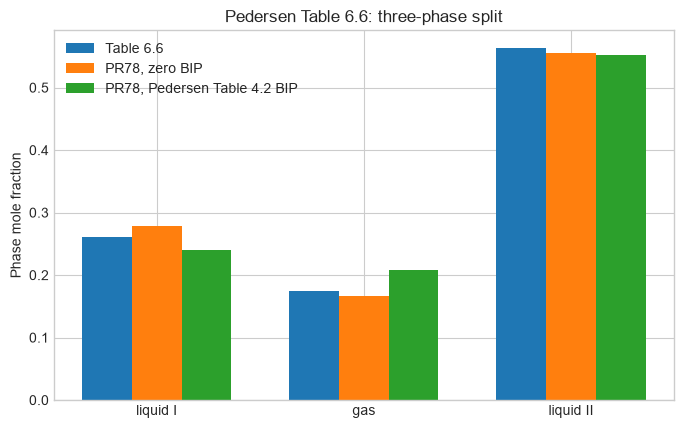

In [4]:
fraction_rows = [
    {"model": "Table 6.6", "phase": phase, "fraction": float(value)}
    for phase, value in zip(
        ("liquid I", "gas", "liquid II"), book_phase_fractions, strict=True
    )
]
for model_name, result in results.items():
    fraction_rows.extend(
        {
            "model": model_name,
            "phase": phase,
            "fraction": float(value),
        }
        for phase, value in zip(
            ("liquid I", "gas", "liquid II"),
            result.phase_fractions,
            strict=True,
        )
    )
fraction_comparison = pd.DataFrame(fraction_rows)
display(fraction_comparison.pivot(index="phase", columns="model", values="fraction"))

fig, axis = plt.subplots(figsize=(8, 4.8))
phase_positions = np.arange(3)
width = 0.24
for offset, (model_name, group) in enumerate(
    fraction_comparison.groupby("model", sort=False)
):
    axis.bar(
        phase_positions + (offset - 1) * width,
        group["fraction"],
        width,
        label=model_name,
    )
axis.set(
    xticks=phase_positions,
    xticklabels=("liquid I", "gas", "liquid II"),
    ylabel="Phase mole fraction",
    title="Pedersen Table 6.6: three-phase split",
)
axis.legend()
plt.show()

## Complete phase compositions

The log scale retains the heavy species in the gas phase. Values printed as
`0.00` in Table 6.6 are left as censored observations below 0.005 mol%, not
interpreted as exact zeros.

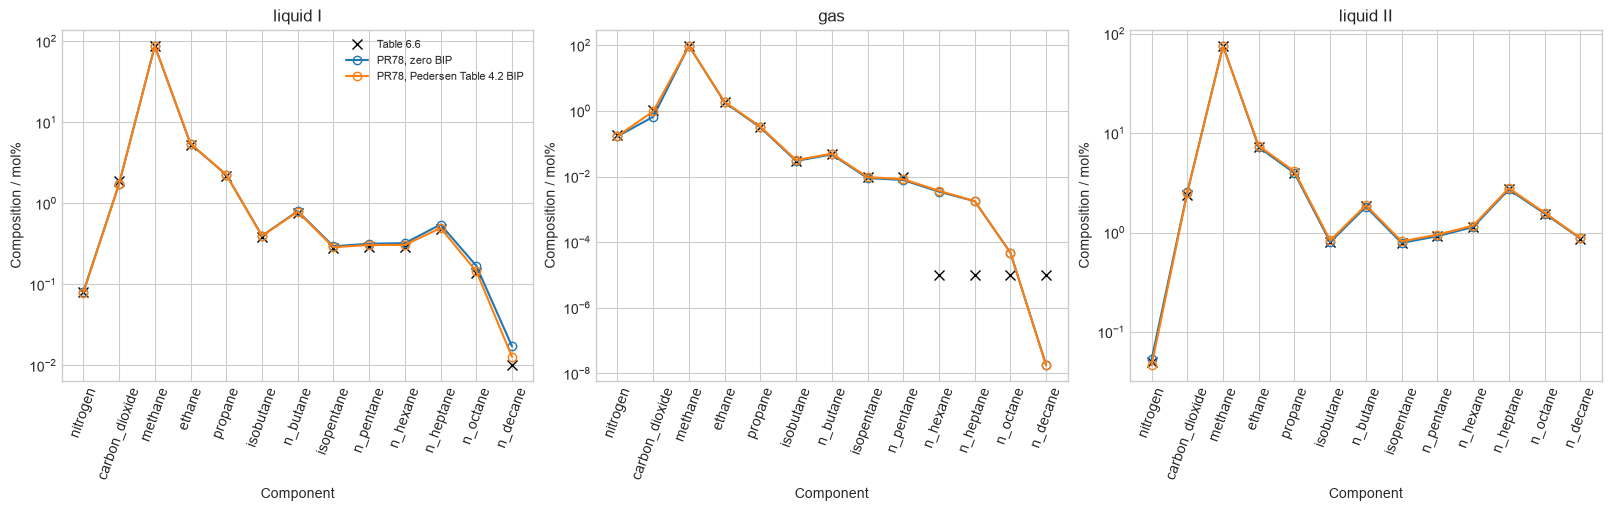

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for phase_index, (axis, phase_name) in enumerate(
    zip(axes, ("liquid I", "gas", "liquid II"), strict=True)
):
    axis.semilogy(
        np.arange(13),
        np.maximum(100.0 * book_phase_compositions[phase_index].numpy(), 1.0e-5),
        "kx",
        markersize=7,
        label="Table 6.6",
    )
    for model_name, result in results.items():
        axis.semilogy(
            np.arange(13),
            100.0 * result.phases[phase_index].composition,
            marker="o",
            fillstyle="none",
            label=model_name,
        )
    axis.set(
        xticks=np.arange(13),
        xticklabels=names,
        xlabel="Component",
        ylabel="Composition / mol%",
        title=phase_name,
    )
    axis.tick_params(axis="x", rotation=70)
axes[0].legend(fontsize=8)
plt.show()

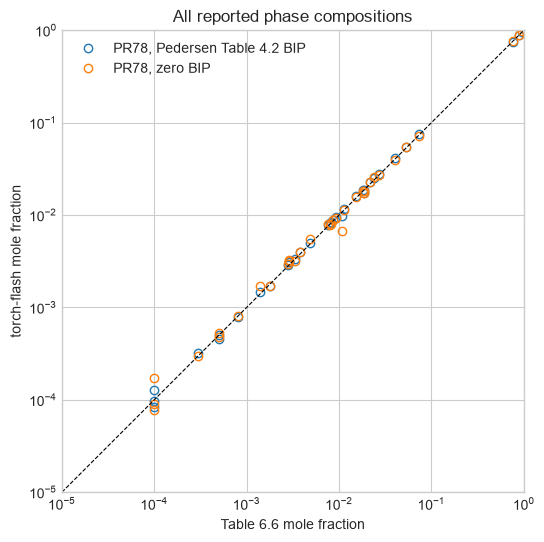

In [6]:
parity_rows = []
for model_name, result in results.items():
    for phase_index, phase_name in enumerate(("liquid I", "gas", "liquid II")):
        for component_name, reference, predicted in zip(
            names,
            book_phase_compositions[phase_index],
            result.phases[phase_index].composition,
            strict=True,
        ):
            if float(reference) > 0.0:
                parity_rows.append(
                    {
                        "model": model_name,
                        "phase": phase_name,
                        "component": component_name,
                        "book": float(reference),
                        "predicted": float(predicted),
                    }
                )
parity = pd.DataFrame(parity_rows)
fig, axis = plt.subplots(figsize=(6, 6))
for model_name, group in parity.groupby("model"):
    axis.loglog(
        group["book"], group["predicted"], "o", fillstyle="none", label=model_name
    )
limits = (1.0e-5, 1.0)
axis.plot(limits, limits, "k--", linewidth=0.8)
axis.set(
    xlim=limits,
    ylim=limits,
    aspect="equal",
    xlabel="Table 6.6 mole fraction",
    ylabel="torch-flash mole fraction",
    title="All reported phase compositions",
)
axis.legend()
plt.show()

## Fixed-three-phase continuation diagnostic

A fixed phase-count solver is not a phase-discovery algorithm. We perturb
temperature while deliberately retaining the Table 6.6 three-phase initial
split and plot the final fugacity residual. Failure away from −72°C means
that this initialization did not establish an admissible three-phase
solution; it must not be graphed as a physical phase fraction.

,temperature_C,residual_norm,converged
0,-75.0,9.731145e+00,False
1,-74.0,9.120492e+00,False
2,-73.0,4.190630e+00,False
3,-72.0,1.643130e-12,True
4,-71.0,6.717390e-02,False
5,-70.0,7.994636e+00,False
6,-69.0,7.939215e+00,False


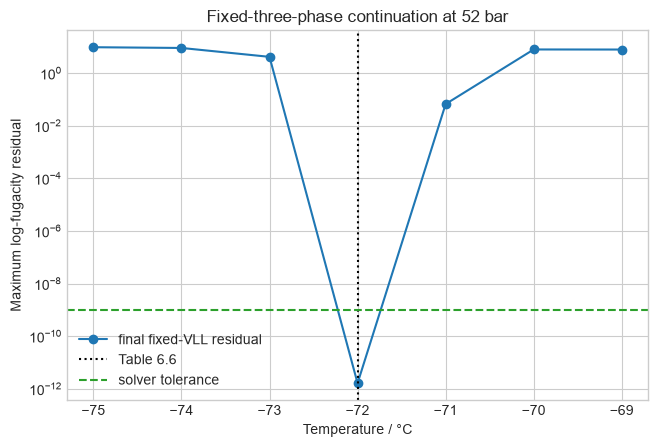

In [7]:
temperature_rows = []
for temperature in torch.linspace(198.15, 204.15, 7):
    local_state = ChemicalState(temperature, state.pressure, state.composition)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        local = multiphase_flash(
            models["PR78, zero BIP"],
            local_state,
            initial_k_values=initial_k,
            tolerance=1.0e-9,
            max_iterations=20,
        )
    temperature_rows.append(
        {
            "temperature_C": float(temperature - 273.15),
            "residual_norm": float(local.residual_norm),
            "converged": local.converged,
        }
    )
temperature_sensitivity = pd.DataFrame(temperature_rows)
display(temperature_sensitivity)

fig, axis = plt.subplots(figsize=(7.5, 4.8))
axis.semilogy(
    temperature_sensitivity["temperature_C"],
    temperature_sensitivity["residual_norm"],
    marker="o",
    label="final fixed-VLL residual",
)
axis.axvline(-72.0, color="black", linestyle=":", label="Table 6.6")
axis.axhline(1.0e-9, color="tab:green", linestyle="--", label="solver tolerance")
axis.set(
    xlabel="Temperature / °C",
    ylabel="Maximum log-fugacity residual",
    title="Fixed-three-phase continuation at 52 bar",
)
axis.legend()
plt.show()

## Interpretation

The zero-BIP reconstruction is closest overall to the printed Table 6.6
phase fractions and hydrocarbon partitions. Pedersen Table 4.2 improves CO₂
partitioning but moves the phase fractions. Since Table 6.6 does not state
the BIP matrix and Table 6.5 rounds three heavy pseudo-components to only
four significant figures, an exact digit-for-digit reconstruction is not
identifiable from the monograph alone. Both calculations nevertheless close
material balance and fugacity equality to numerical tolerances.